> [!IMPORTANT]
> **Jupyter Notebooks are sequential.** To avoid `NameError`, you must run all cells in order from top to bottom.
> 
> **Shortcut:** Go to the menu and select **Cell > Run All** or **Kernel > Restart & Run All** to run the complete project at once.

# Random Forest - Ecommerce Seasonality Prediction

This notebook implements a Random Forest model to predict Whether a product has 'Seasonality' based on various ecommerce features.

## 0. Install/Upgrade Required Libraries
Run this cell to ensure all necessary libraries are installed in your current environment.

In [1]:
%pip install --upgrade pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Library Files

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2. Data Cleaning and Pre-processing

In [3]:
# Load the dataset
df = pd.read_csv('diversified_ecommerce_dataset.csv')

# Display first few rows
print("Dataset Shape:", df.shape)
# display(df.head()) # Use print if display is not available
print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop Product ID as it's just an identifier
df = df.drop(['Product ID'], axis=1)

# Encode categorical variables
le = LabelEncoder()
categorical_cols = ['Product Name', 'Category', 'Supplier ID', 'Customer Age Group', 'Customer Location', 'Customer Gender', 'Shipping Method']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Target encoding
df['Seasonality'] = df['Seasonality'].map({'Yes': 1, 'No': 0})

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['Price', 'Discount', 'Tax Rate', 'Stock Level', 'Shipping Cost', 'Return Rate', 'Popularity Index']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\nPreprocessed Data:")
print(df.head())

Dataset Shape: (1000000, 16)
  Product ID Product Name     Category    Price  Discount  Tax Rate  \
0      P6879       Jacket      Apparel    53.85         5        15   
1      P5132       Camera  Electronics   761.26        10        15   
2      P2941     Sneakers     Footwear  1756.76         5         8   
3      P8545    Cookbooks        Books   295.24        10        15   
4      P4594       Camera  Electronics   832.00        10        12   

   Stock Level Supplier ID Customer Age Group Customer Location  \
0          150        S535              35-44     New York, USA   
1          224        S583              25-34        London, UK   
2          468        S118              25-34      Tokyo, Japan   
3           25        S104              18-24     Paris, France   
4          340        S331                55+      Tokyo, Japan   

  Customer Gender  Shipping Cost Shipping Method  Return Rate Seasonality  \
0            Male          23.32        Standard         4.49   

## 3 & 4. Data Training, Testing and Algorithm Implementation


In [4]:
# 1. Check if data is loaded
if 'df' not in locals():
    print("Error: Dataset 'df' not found. Please run the 'Data Cleaning' cell above.")
else:
    # 2. Define features and target
    X = df.drop('Seasonality', axis=1)
    y = df['Seasonality']

    # 3. Split the data (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"Training set size: {X_train.shape}")
    print(f"Testing set size: {X_test.shape}")

    # 4. Initialize and train Random Forest model
    print("Training Random Forest model...")
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 5. Make predictions
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Training set size: (800000, 14)
Testing set size: (200000, 14)
Training Random Forest model...

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.53      0.52    100218
           1       0.50      0.46      0.48     99782

    accuracy                           0.50    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       0.50      0.50      0.50    200000



## 5. Evaluation Parameter Visualization

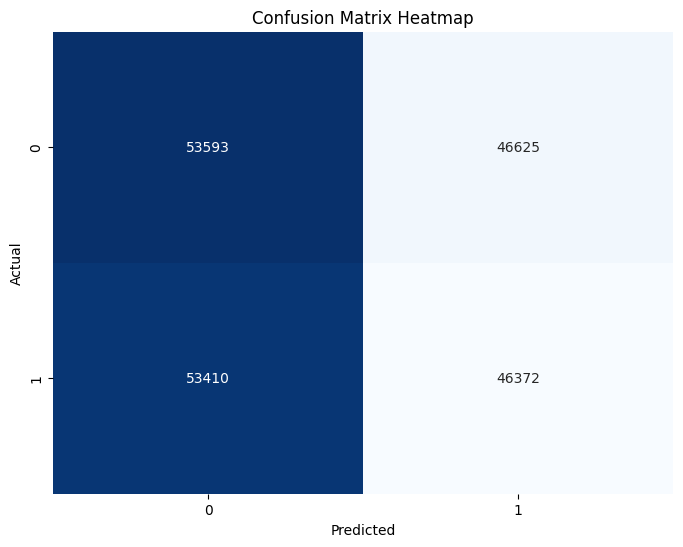

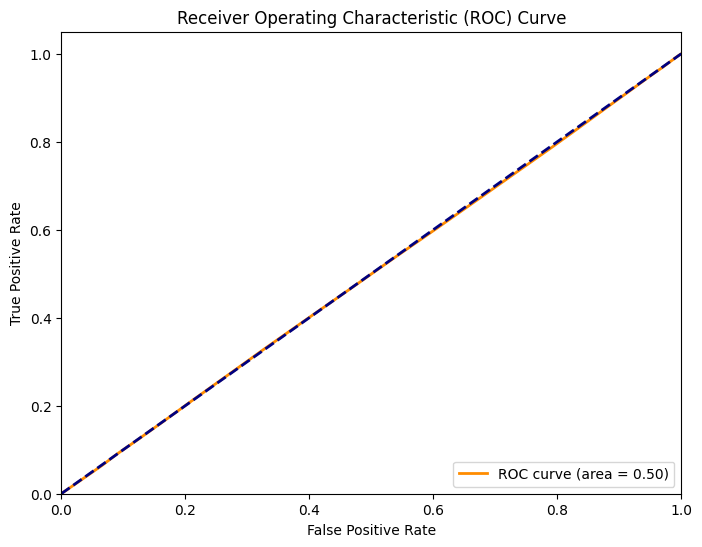

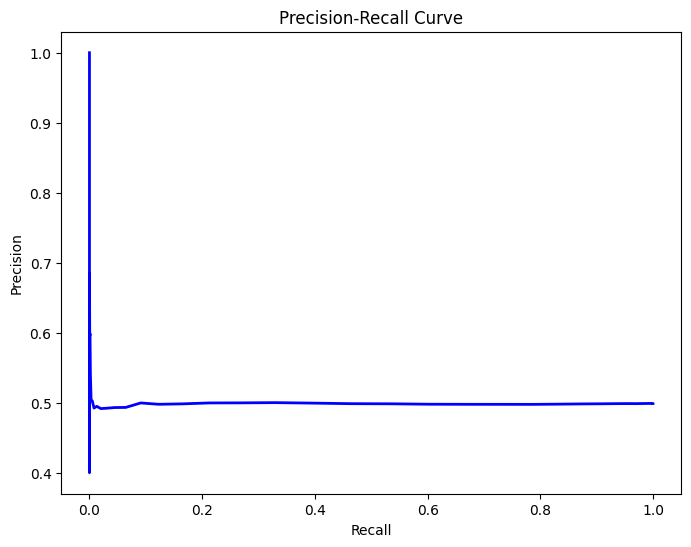

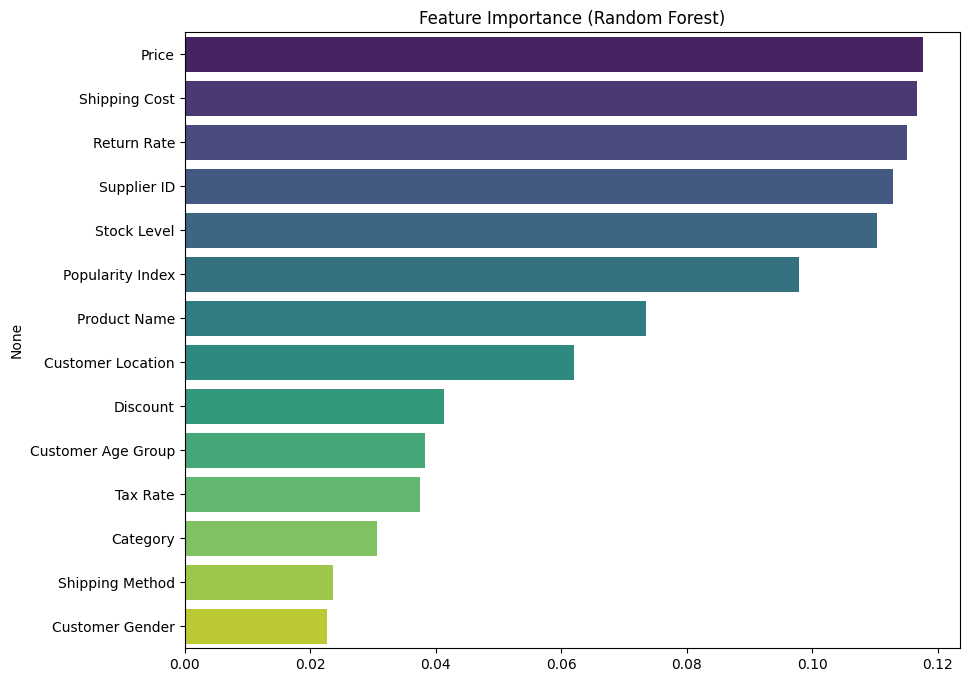

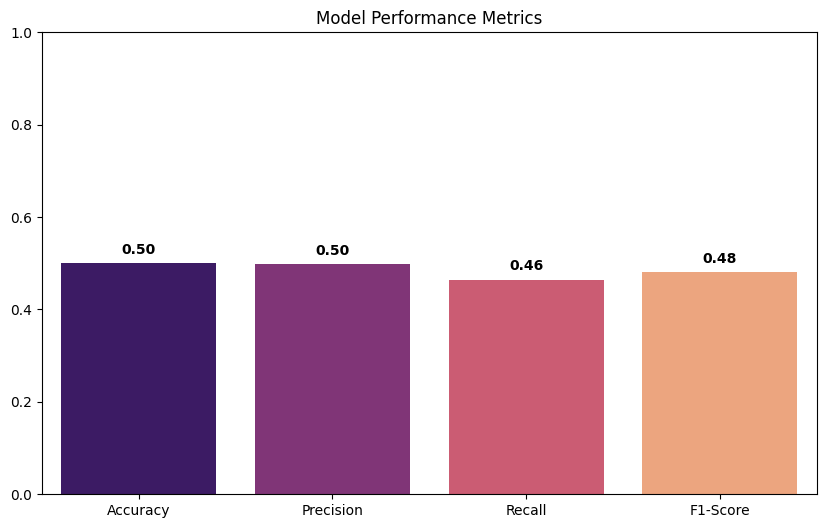

In [5]:
# 1. Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# 4. Feature Importance / Probability Distribution
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.show()

# 5. Performance Metrics Bar Chart
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred)
}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='magma')
plt.title('Model Performance Metrics')
plt.ylim(0, 1)
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.show()